    Sprint 1

In [3]:
!pip install --upgrade s3fs fsspec

    Початковий датасет train_age.csv обсягом 210 000 записів було локально стратифіковано через PyCharm перед завантаженням в AWS. Вибірку було скорочено до 50% (105 000 рядків) із суворим збереженням пропорцій усіх шести вікових класів цільової змінної.

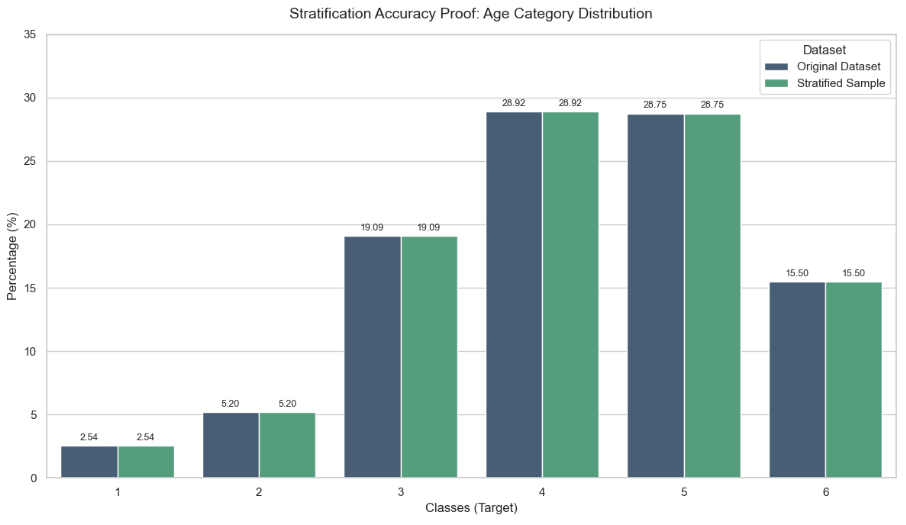

In [1]:
# Імпортуємо датасет

import pandas as pd

path = "../data/cleaned_dataset_stratified.csv"
df = pd.read_csv(path, engine='pyarrow')
df.head()

,target,CALCULATION_METHOD_ID,calls_count_in_weekdays,calls_duration_in_weekdays,calls_count_out_weekdays,calls_duration_out_weekdays,calls_count_in_weekends,calls_duration_in_weekends,calls_count_out_weekends,calls_duration_out_weekends,...,ttSMS,ttt.ua,uklon,ukrazom.or,ukrazom.org,ukrmir,upgood,www.add.ua,xiaomi,ya888ya
0,4,2,3.78,8.096,3.30,6.269,1.88,2.185,1.13,2.940,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,6,2,1.83,2.780,2.26,3.081,2.50,6.946,1.00,3.208,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5,1,0.78,1.129,0.39,0.670,0.25,2.171,0.38,4.465,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,2,6.96,16.996,6.87,12.451,4.38,12.871,1.63,3.985,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2,2.87,10.517,3.70,12.391,2.00,1.935,3.13,12.427,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


1. Business & Data Understanding

Задача: Vodafone Age — Multiclass Classification.
Що прогнозуємо: Вікову категорію абонента на основі його активності (дзвінки, тривалість, використання інтернету тощо).
Бізнес-цінність: Модель дозволить компанії пропонувати більш релевантні тарифи, персоналізовані послуги та таргетовану рекламу для різних вікових груп.
Ціна помилки: - Найбільш критичні помилки (FP/FN) — це сплутати неповнолітнього користувача з дорослим (наприклад, показ реклами 18+ дітям).

2. Initial Data Exploration:

1.Розмірність: Датасет великий (210 000 записів, 1294 ознак). Очевидно присутній "шум" та надлишковість даних.
2.Дисбаланс класів: Класи 4 і 5 є домінуючими (близько 60% в сумі), тоді як клас 1 становить менше 5%. Це вимагатиме балансування ваг під час навчання моделі.
3.Природа пропусків (NaN): У багатьох колонках (наприклад, інтернет-трафік за категоріями "Игры", "Знакомства") кількість пропусків перевищує 50%. З точки зору бізнес-логіки це не "втрачені дані", а відсутність активності користувача у цій категорії. Тому правильним підходом буде заповнення таких пропусків нулями, а не медіаною чи середнім.
4. Типи ознак: Переважна більшість даних (понад 98%) є числовими ознаками типу float64, що є сприятливим для математичних моделей. Виявлені 14 текстових ознак було проаналізовано окремо для подальшого кодування або видалення. 
5. Потенційний leakage: Під час аналізу 1294 ознак не було виявлено явних ознак витоку даних (наприклад, прямих вказівок на вікову групу в технічних параметрах). Проте велика кількість ознак потребує подальшого моніторингу через Feature Importance після побудови першої моделі.

Розмір датасету: 105000 рядків, 1294 колонок


,target,CALCULATION_METHOD_ID,calls_count_in_weekdays,calls_duration_in_weekdays,calls_count_out_weekdays,calls_duration_out_weekdays,calls_count_in_weekends,calls_duration_in_weekends,calls_count_out_weekends,calls_duration_out_weekends,...,ttSMS,ttt.ua,uklon,ukrazom.or,ukrazom.org,ukrmir,upgood,www.add.ua,xiaomi,ya888ya
count,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000,...,100675.000000,100675.000000,100675.000000,100675.000000,100675.000000,100675.000000,100675.00000,100675.000000,100675.000000,100675.000000
mean,4.226181,1.498857,4.984116,11.114840,5.207754,12.073558,3.078145,7.828976,3.309543,8.628946,...,0.075242,0.045423,0.410042,0.010132,0.005225,0.031011,0.02522,0.034944,0.052496,0.002424
std,1.218246,0.500001,8.320171,12.617764,10.123900,15.461983,8.374209,11.377567,9.913474,13.626238,...,0.769054,0.649958,4.715600,0.183168,0.124451,0.397626,0.29341,0.440593,0.777957,0.069151
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,3.000000,1.000000,1.220000,2.464750,1.040000,2.085000,0.630000,1.056000,0.500000,0.850000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,4.000000,1.000000,3.350000,7.515500,3.300000,7.517000,2.000000,4.398000,2.000000,4.467000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,5.000000,2.000000,6.700000,15.764000,6.870000,16.682000,4.130000,10.525000,4.380000,11.450000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
max,6.000000,2.000000,1406.830000,745.301000,1116.260000,813.481000,1678.750000,938.306000,1493.250000,881.021000,...,120.000000,24.000000,360.000000,10.000000,7.000000,46.000000,15.00000,22.000000,187.000000,7.000000


float64    1275
object       14
int64         5
Name: count, dtype: int64

Интернет провайдеры          53.781905
Интернет издания             53.781905
Изобразительное искусство    53.781905
Игры                         53.781905
Игровые приставки, игры      53.781905
Зоотовары_2                  53.781905
Знакомства                   53.781905
Здоровый образ жизни         53.781905
Поиск людей                  53.781905
Непознанное                  53.781905
dtype: float64

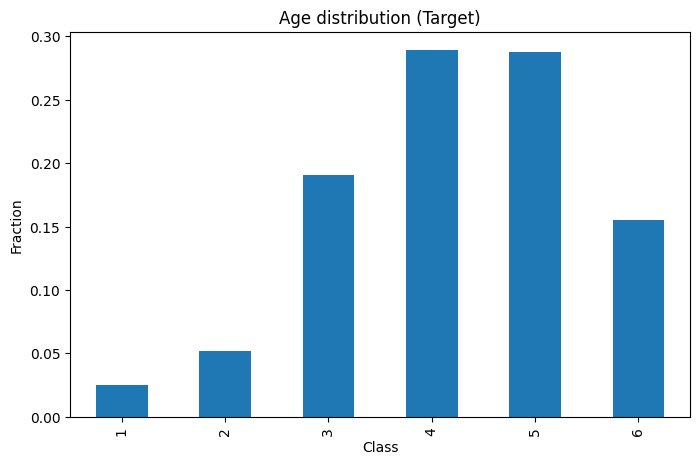

In [2]:
# Data Exploration
# Розмірність датасету
print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")

# Описова статистика для основних числових колонок
display(df.describe())

# Типи фіч
display(df.dtypes.value_counts())

# Частка пропусків ( топ-10 колонок з найбільшою кількістю NaN)
missing_percentages = df.isna().mean() * 100
display(missing_percentages.sort_values(ascending=False).head(10))

# Target distribution (розподіл класів)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df['target'].value_counts(normalize=True).sort_index().plot(kind='bar')
plt.title('Age distribution (Target)')
plt.ylabel('Fraction')
plt.xlabel('Class')
plt.show()

3. Data Cleaning:

Цей етап готує сирі дані до аналізу, виконуючи лише базове очищення без складних перетворень. Було збережено 105 000+ рядків для забезпечення точності моделей, а зі старту видалено технічний ідентифікатор user_hash. Надалі було застосовано простий Feature Filtering: автоматично знайдено та видалено константні й «майже константні» ознаки (де одне значення займає понад 99% стовпця) для усунення інформаційного шуму. Наостанок, керуючись бізнес-логікою телекомунікаційної сфери, усі пропуски (NaN) у числових колонках було заповнено нулями, оскільки відсутність логів свідчить про нульову активність абонента. Цільову змінну target було залишено без змін.

In [ ]:
import numpy as np
import pandas as pd
import gc
import os

print(f"Початкова розмірність: {df.shape}")

# 1. Видалення user_hash (технічний ідентифікатор)
if 'user_hash' in df.columns:
    df.drop(columns=['user_hash'], inplace=True)
    print("Видалено колонку: user_hash")

# 2. Простий feature filtering
nunique_counts = df.nunique(dropna=False)
constant_features = nunique_counts[nunique_counts <= 1].index.tolist()

# Знаходимо майже константні (де одне значення займає > 99%)
near_constant_features = [
    col for col in df.columns 
    if col not in constant_features and df[col].value_counts(normalize=True, dropna=False).values[0] > 0.99
]

features_to_drop = constant_features + near_constant_features

# Вивід списку видалених колонок
print(f"Видалено константних/майже константних ознак: {len(features_to_drop)}")
if len(features_to_drop) > 0:
    print(f"Список видалених колонок: {features_to_drop}")

df.drop(columns=features_to_drop, inplace=True)
gc.collect()

# 3. Обробка пропусків за бізнес-логікою (відсутність логів = 0 активності)
numeric_cols = df.select_dtypes(include=[np.number]).columns
features_to_fill = [col for col in numeric_cols if col != 'target']

fill_dict = {col: 0 for col in features_to_fill}
df.fillna(value=fill_dict, inplace=True)

# Збереження результату для подальшого навчання моделей
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/cleaned_dataset.csv', index=False)

print(f"Фінальна розмірність базового датасету: {df.shape}")

Початкова розмірність: (105000, 1294)
Видалено колонку: user_hash
Видалено константних/майже константних ознак: 12
Список видалених колонок: ['SBERBANK', 'PIVDENNYI', 'PRAVEXBANK', 'SUNOIL', 'BRSM', 'AMIC', 'TNK', 'UPG', 'tinder_volume', 'tinder_count', 'netflix_volume', 'netflix_count']


    Звіт по Sprint 1

    У рамках першого спринту було успішно формалізовано бізнес-задачу багатокласової класифікації вікових категорій абонентів Vodafone та проведено базовий розвідувальний аналіз (EDA). Дослідження сирого датасету обсягом 210 000 записів на 1294 ознаки виявило суттєвий дисбаланс цільової змінної: класи 4 та 5 сумарно складають близько 60% вибірки, тоді як 1 клас — менше 5%. Також було проаналізовано типи даних, де переважна більшість (1275 колонок) виявилася числового формату (float64), та визначено природу пропусків, які з точки зору бізнес-логіки означають просто відсутність активності абонента в певних категоріях.

    На етапі очищення даних було підготовлено чистий baseline-датасет, зі свідомою відмовою від штучного урізання вибірки для збереження максимальної точності. Для зменшення інформаційного шуму було вилучено технічний ідентифікатор, а також проведено простий feature filtering, який автоматично видалив 13 константних і майже константних ознак. Усі пропуски в числових колонках було заповнено нулями, що повністю відповідає логіці відсутності логів активності. У результаті було сформовано та збережено фінальний базовий набір даних розмірністю 210 000 рядків на 1281 колонку, який повністю готовий до побудови перших моделей.